# 04 – FAERS Exploratory Data Analysis

Characterize reporting volume, seriousness, demographics, top drugs, top reactions, and immune-related events. FAERS complements preclinical assays by providing real-world safety-reporting evidence, but it is subject to major reporting and confounding biases.

In [1]:
from pathlib import Path
import sys, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent
if not (ROOT/"data").exists(): ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

from src.preprocessing import load_faers, flag_immune_reactions, serious_report_flag

path = ROOT/"data/raw/faers/fda_adverse_events_2015_2026_CLEAN.csv"
if not path.exists(): path = ROOT/"fda_adverse_events_2015_2026_CLEAN.csv"
df = load_faers(path)
df["receive_date"] = pd.to_datetime(df["receive_date"], errors="coerce")
print(df.shape)
display(df.head())

(528000, 30)


,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


In [2]:
quality = pd.DataFrame({"missing_n":df.isna().sum(),
                              "missing_pct":df.isna().mean()*100,
                              "unique_n":df.nunique(dropna=True)}).sort_values("missing_pct", ascending=False)
display(quality.head(20))
print("Date range:", df["receive_date"].min(), "to", df["receive_date"].max())
print("Duplicate report_id:", df["report_id"].duplicated().sum())

,missing_n,missing_pct,unique_n
patient_weight_kg,379923,71.955114,5872
serious_flags,301106,57.027652,31
patient_age_years,151509,28.694886,3657
month,0,0.000000,12
year,0,0.000000,11
report_id,0,0.000000,528000
serious,0,0.000000,2
is_fatal,0,0.000000,2
is_hospitalized,0,0.000000,2
is_life_threat,0,0.000000,2


Date range: 2015-01-01 00:00:00 to 2025-12-31 00:00:00
Duplicate report_id: 0


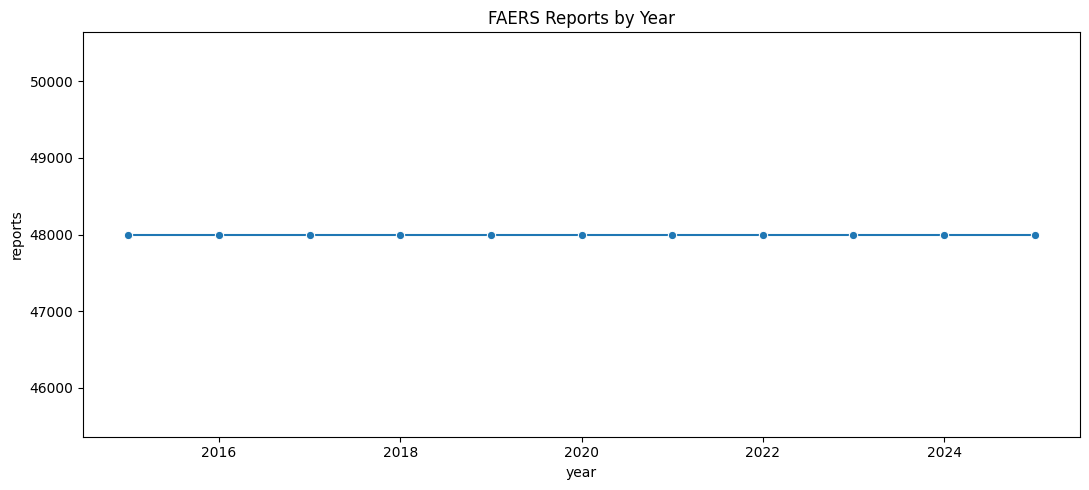

Serious reports: 395000 (74.81%)


In [3]:
annual = df.groupby("year").size().reset_index(name="reports")
plt.figure(figsize=(11,5))
sns.lineplot(data=annual, x="year", y="reports", marker="o")
plt.title("FAERS Reports by Year")
plt.tight_layout()
plt.savefig(ROOT/"reports/figures/faers_reports_by_year.png", dpi=200)
plt.show()

serious = serious_report_flag(df)
print("Serious reports:", int(serious.sum()), f"({serious.mean()*100:.2f}%)")

In [4]:
df["is_immune_related"] = flag_immune_reactions(
    df["reactions"].fillna("").astype(str) + " " + df["primary_reaction"].fillna("").astype(str)
)
display(df.loc[df["is_immune_related"], ["report_id","suspect_drug","primary_reaction"]].head(20))

display(df["suspect_drug"].fillna("UNKNOWN").value_counts().head(20).to_frame("reports"))
display(df["primary_reaction"].fillna("UNKNOWN").value_counts().head(20).to_frame("reports"))

,report_id,suspect_drug,primary_reaction
4,10005980,CETIRIZINE HYDROCHLORIDE; CETIRIZINE; CETIRIZI...,Angioedema
54,10014029,PEGINTERFERON ALFA-2A,Drug interaction
96,10029286,METAMIZOLE,Angioedema
98,10031038,ETANERCEPT,Arthralgia
136,10048529,ADALIMUMAB,Skin ulcer
160,10056930,TEMSIROLIMUS; TEMSIROLIMUS INJECTION,Hypersensitivity
179,10062129,ECULIZUMAB,Urticaria
224,10080173,ECULIZUMAB,Neutropenia
241,10085790,ZIPRASIDONE; ZIPRASIDONE MESYLATE; ZIPRASIDONE...,Drug hypersensitivity
4098,10040223,IBUPROFEN; IBUPROFEN CAPSULES 200 MG; IBUPROFE...,Anaphylactic reaction


,reports
suspect_drug,
TOFACITINIB,13807
RISPERIDONE,13487
RIVAROXABAN,12968
AVANDIA,10091
ETANERCEPT,8751
DUPILUMAB,8246
ADALIMUMAB,8131
SODIUM OXYBATE,8008
VEDOLIZUMAB,7875


,reports
primary_reaction,
Drug ineffective,10437
Death,9371
Pneumonia,5510
Drug hypersensitivity,5492
Myocardial infarction,5317
Gynaecomastia,5153
Chronic kidney disease,5083
Off label use,4934
Gastrointestinal haemorrhage,4802


In [5]:
OUT = ROOT/"data/processed/faers"
OUT.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUT/"faers_eda_enriched.parquet")
quality.to_csv(OUT/"faers_quality.csv")
annual.to_csv(OUT/"faers_annual_counts.csv", index=False)
print("FAERS EDA artifacts saved.")

FAERS EDA artifacts saved.


### Caveats

The immune flag is a transparent keyword screen, not a validated MedDRA concept set. Production pharmacovigilance should use controlled terminology, duplicate assessment, indication stratification, exposure context, and expert review.